In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

try:
    from tabpfn import TabPFNRegressor
    from tabpfn.constants import ModelVersion
except ImportError as exc:
    raise ImportError(
        "tabpfn is not installed. Run `%pip install tabpfn` in a notebook cell, then rerun."
    ) from exc

In [2]:
csv_path = "interfacial_results_dataset_A1.csv"
combined_df = pd.read_csv(csv_path)

print(f"Loaded {csv_path} with shape: {combined_df.shape}")
combined_df.head()

Loaded interfacial_results_dataset_A1.csv with shape: (19171, 74)


,temperature,pressure,z_carbon dioxide,z_hydrogen,z_nitrogen,z_argon,z_methane,z_oxygen,z_water,z_carbon monoxide,...,E_sulfur dioxide,E_hydrogen sulfide,E_propane,E_ethane,gamma0_CO2,rhoL0_CO2,rhoV0_CO2,Tc_CO2,Psat_CO2,source_id
0,200.0,2.523496,0.95,0.005733,0.0,0.0,0.0,0.016922,0.0,0.027345,...,0.0,0.0,0.0,0.0,19.912634,1222.376153,6.589392,309.147376,2.392259,0
1,200.0,6.239821,0.95,0.005733,0.0,0.0,0.0,0.016922,0.0,0.027345,...,0.0,0.0,0.0,0.0,19.912634,1222.376153,6.589392,309.147376,2.392259,0
2,200.0,9.956146,0.95,0.005733,0.0,0.0,0.0,0.016922,0.0,0.027345,...,0.0,0.0,0.0,0.0,19.912634,1222.376153,6.589392,309.147376,2.392259,0
3,200.0,13.672471,0.95,0.005733,0.0,0.0,0.0,0.016922,0.0,0.027345,...,0.0,0.0,0.0,0.0,19.912634,1222.376153,6.589392,309.147376,2.392259,0
4,200.0,17.388795,0.95,0.005733,0.0,0.0,0.0,0.016922,0.0,0.027345,...,0.0,0.0,0.0,0.0,19.912634,1222.376153,6.589392,309.147376,2.392259,0


In [3]:
target = "gamma"

COMPONENTS = [
    "carbon dioxide",
    "hydrogen",
    "argon",
    "nitrogen",
    "methane",
    "oxygen",
    "carbon monoxide",
    "hydrogen sulfide",
]

z_columns = [f"z_{comp}" for comp in COMPONENTS]
feature_cols = [
    col for col in combined_df.columns
    if col in ["temperature", "pressure"] + z_columns
]

required_cols = feature_cols + [target]
df_model = combined_df[required_cols].dropna().copy()

X = df_model[feature_cols]
y = df_model[target]

print("Selected features:", feature_cols)
print(f"Rows after dropna on features + target: {len(df_model)}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']
Rows after dropna on features + target: 19171


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=85
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows:  {X_test.shape[0]}")

Training rows: 15336
Testing rows:  3835


In [5]:
os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"

tabpfn_model = TabPFNRegressor(
    random_state=85,
    ignore_pretraining_limits=True,
    fit_mode="fit_preprocessors",
)
tabpfn_model.fit(X_train, y_train)

y_pred_train = tabpfn_model.predict(X_train)
y_pred_test = tabpfn_model.predict(X_test)

print("TabPFN model training completed.")

TabPFN model training completed.


In [6]:
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

train_metrics = regression_metrics(y_train, y_pred_train)
test_metrics = regression_metrics(y_test, y_pred_test)

metrics_df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
metrics_df

,R2,RMSE,MAE
Train,0.999989,0.017712,0.006895
Test,0.999985,0.020888,0.007992


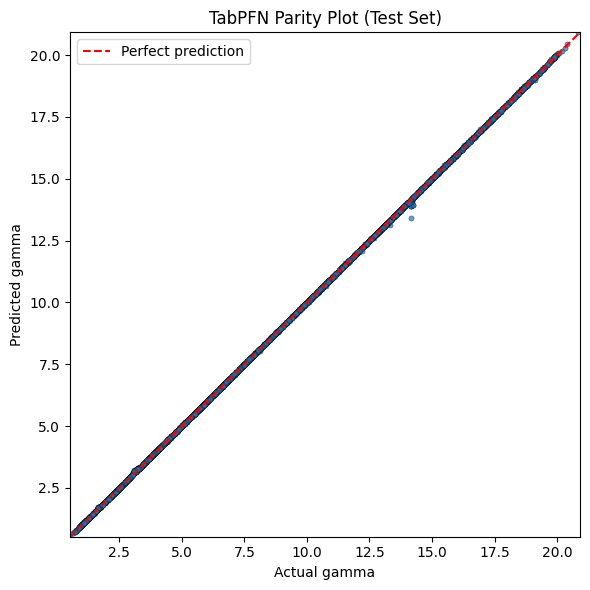

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))

lims = [
    min(y_test.min(), np.min(y_pred_test)),
    max(y_test.max(), np.max(y_pred_test)),
]

ax.scatter(y_test, y_pred_test, s=14, alpha=0.7, color="#1f77b4", edgecolor="black", linewidth=0.3)
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual gamma")
ax.set_ylabel("Predicted gamma")
ax.set_title("TabPFN Parity Plot (Test Set)")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
pred_df = X_test.copy()
pred_df["gamma_actual"] = y_test.values
pred_df["gamma_pred_tabpfn"] = y_pred_test

pred_df.to_csv("tabpfn_test_predictions.csv", index=False)
print("Saved predictions to tabpfn_test_predictions.csv")
pred_df.head()

Saved predictions to tabpfn_test_predictions.csv


,temperature,pressure,z_carbon dioxide,z_hydrogen,z_nitrogen,z_argon,z_methane,z_oxygen,z_carbon monoxide,z_hydrogen sulfide,gamma_actual,gamma_pred_tabpfn
4330,275.0,37.256439,0.990000,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.0,4.105066,4.103269
13242,245.0,15.527731,0.980000,0.014697,0.000000,0.000000,0.002563,0.000333,0.002407,0.0,9.859954,9.870987
8506,250.0,19.386534,0.990000,0.000000,0.000000,0.003023,0.003007,0.003970,0.000000,0.0,8.646487,8.647531
12605,210.0,8.725639,0.949999,0.000410,0.003068,0.000000,0.024408,0.022115,0.000000,0.0,15.886195,15.884888
13969,220.0,7.891495,0.960000,0.000000,0.000000,0.030000,0.000000,0.000000,0.010000,0.0,14.906069,14.899911
